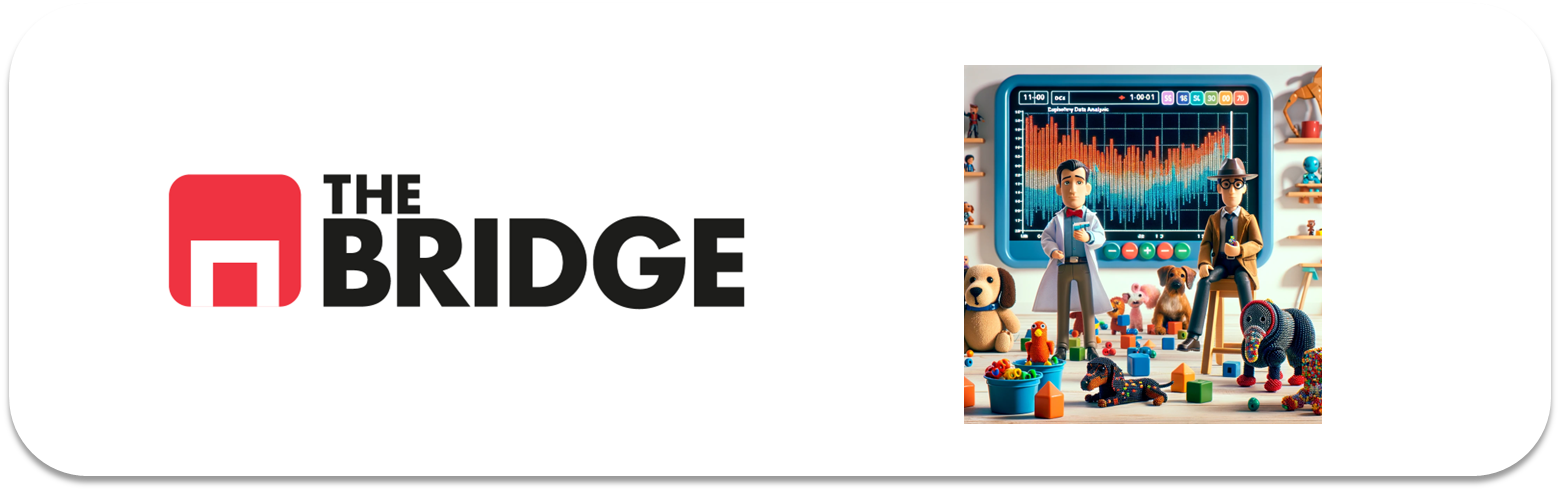

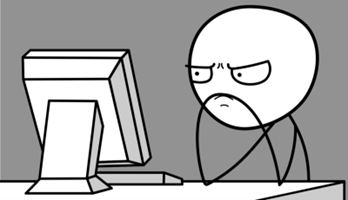

Para ejercitarte y afianzar lo aprendido sobre el análisis bivariante, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos se subirá a lo largo del sprint.

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Ejercicio 1

Carga el dataset de admisiones que conoces de la unidad anterior y que se encuentra en la ruta "./data/admission_data.csv", deshazte de las columnas innecesarias

In [2]:
df=pd.read_csv("./data/admission_data.csv")

In [3]:
df.info

<bound method DataFrame.info of        Unnamed: 0  Year                                 Major Gender Admission
0               0  1973                    School of Medicine      F  Rejected
1               1  1973               Department of Economics      M  Accepted
2               2  1973                                 Other      F  Accepted
3               3  1973                                 Other      M  Accepted
4               4  1973                                 Other      M  Rejected
...           ...   ...                                   ...    ...       ...
12758       12758  1973                                 Other      M  Accepted
12759       12759  1973  Department of Mechanical Engineering      M  Accepted
12760       12760  1973                                 Other      F  Rejected
12761       12761  1973                                 Other      M  Rejected
12762       12762  1973                                 Other      M  Accepted

[12763 rows x 5 col

In [4]:
display(df)

,Unnamed: 0,Year,Major,Gender,Admission
0,0,1973,School of Medicine,F,Rejected
1,1,1973,Department of Economics,M,Accepted
2,2,1973,Other,F,Accepted
3,3,1973,Other,M,Accepted
4,4,1973,Other,M,Rejected
...,...,...,...,...,...
12758,12758,1973,Other,M,Accepted
12759,12759,1973,Department of Mechanical Engineering,M,Accepted
12760,12760,1973,Other,F,Rejected
12761,12761,1973,Other,M,Rejected


In [5]:
df.Year.unique()

array([1973])

In [6]:
def cardinalidad(df_in: pd.DataFrame, umbral_categoria: int, umbral_continua: float) -> pd.DataFrame:
    resultados = []

    n_filas = len(df_in)

    for col in df_in.columns:
        valores_unicos = df_in[col].nunique(dropna=False)
        porcentaje = (valores_unicos / n_filas)

        if valores_unicos == 2:
            tipo = "Binaria"
        elif valores_unicos < umbral_categoria:
            tipo = "Categórica"
        else:
            if porcentaje >= umbral_continua:
                tipo = "Numerica Continua"
            else:
                tipo = "Numerica Discreta"

        resultados.append({
            "columna": col,
            "cardinalidad": valores_unicos,
            "porcentaje_cardinalidad": porcentaje,
            "tipo": tipo
        })

    return pd.DataFrame(resultados)

In [7]:
cardinalidad(df,10,10)

,columna,cardinalidad,porcentaje_cardinalidad,tipo
0,Unnamed: 0,12763,1.000000,Numerica Discreta
1,Year,1,0.000078,Categórica
2,Major,7,0.000548,Categórica
3,Gender,2,0.000157,Binaria
4,Admission,2,0.000157,Binaria


### Ejercicio 2

Haz el análisis bivariante de "Admission" y "Major" (emplea las funciones del workout importándolas del módulo `bootcampviztools`, o utiliza las visualizaciones del notebook en el repositorio) y contesta a las siguientes preguntas:
* ¿Cuál es el departamento con el mayor porcentaje de admsiones?¿Y el de menor?
* ¿Existe alguna diferencia destacada entre los departamentos?

In [20]:
from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_numerical_relationship

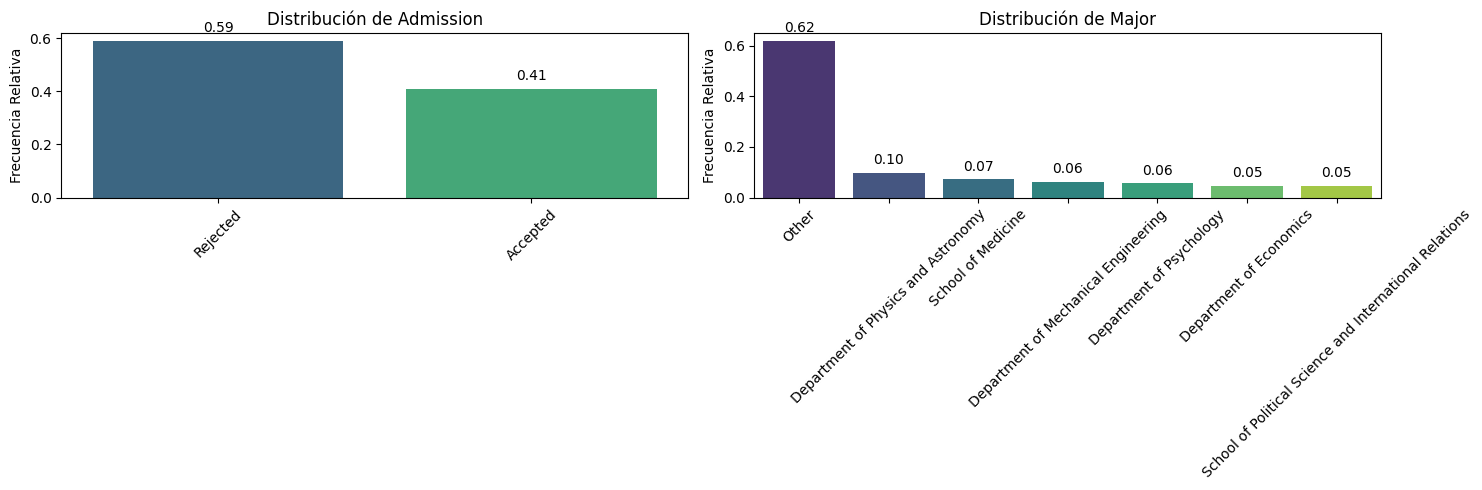

In [11]:
pinta_distribucion_categoricas(df,["Admission","Major"],relativa=True, mostrar_valores=True)

### Ejercicio 3

Repite el análisis para "Admission" y "Gender" y responde a las siguientes preguntas:
* ¿Existe una diferencia visual significativa entre el porcentaje de admitidos de cada género?
* ¿Cuál de los dos grupos tiene más admisiones?

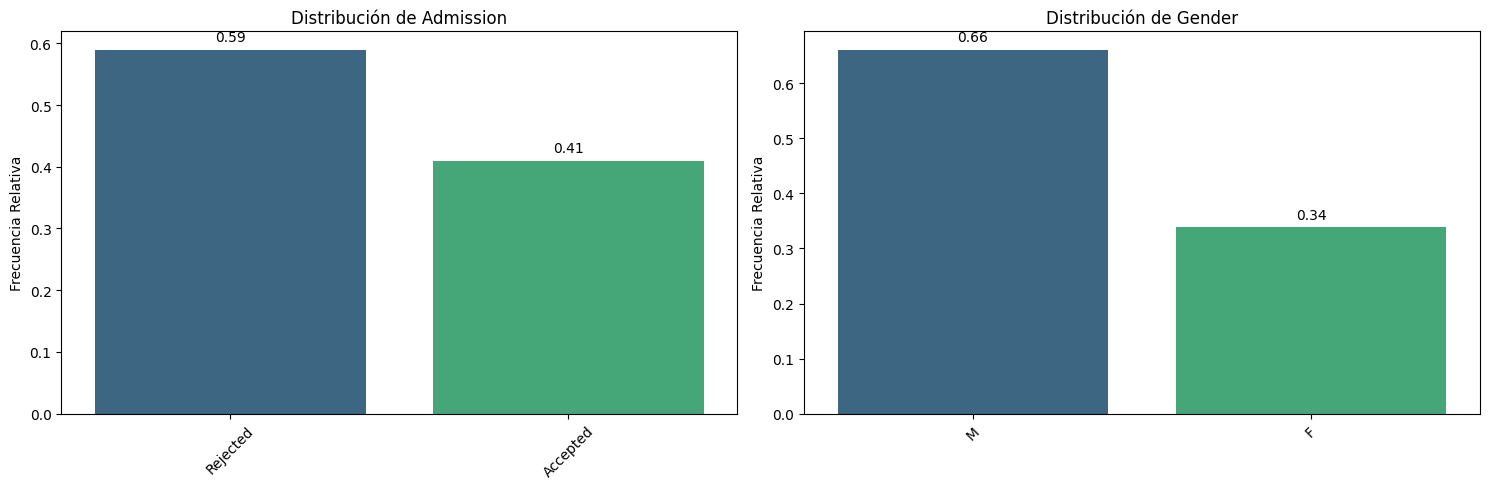

In [12]:
pinta_distribucion_categoricas(df,["Admission","Gender"],relativa=True, mostrar_valores=True)

### Ejercicio 4

Carga el dataset de propinas (tips) que conoces de la unidad anterior y que se encuentra en la ruta "./data/tips.csv", deshazte de las columnas innecesarias

In [13]:
df=pd.read_csv("./data/tips.csv")
display(df)

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


In [16]:
print(df.dtypes)
print(df.shape)

Unnamed: 0      int64
total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object
(244, 8)


In [17]:
cardinalidad(df,10,10)

,columna,cardinalidad,porcentaje_cardinalidad,tipo
0,Unnamed: 0,244,1.000000,Numerica Discreta
1,total_bill,229,0.938525,Numerica Discreta
2,tip,123,0.504098,Numerica Discreta
3,sex,2,0.008197,Binaria
4,smoker,2,0.008197,Binaria
5,day,4,0.016393,Categórica
6,time,2,0.008197,Binaria
7,size,6,0.024590,Categórica


In [29]:
df.describe()

,Unnamed: 0,total_bill,tip,size
count,244.000000,244.000000,244.000000,244.000000
mean,121.500000,19.785943,2.998279,2.569672
std,70.580923,8.902412,1.383638,0.951100
min,0.000000,3.070000,1.000000,1.000000
25%,60.750000,13.347500,2.000000,2.000000
50%,121.500000,17.795000,2.900000,2.000000
75%,182.250000,24.127500,3.562500,3.000000
max,243.000000,50.810000,10.000000,6.000000


### Ejercicio 5

Haz el análisis bivariante de "tip" y "sex" (emplea las funciones del workout importándolas del módulo `bootcampviztools`, o utiliza las visualizaciones del notebook en el repositorio), añade el cálculo de la media y mediana de la variable continua por cada valor de la variable categórica, y contesta a las siguientes preguntas:
* ¿Existe alguna diferencia visualmente significativa entre las propinas de los grupos de la variable "sex"?
* ¿Son diferentes respecto al  conjunto total?

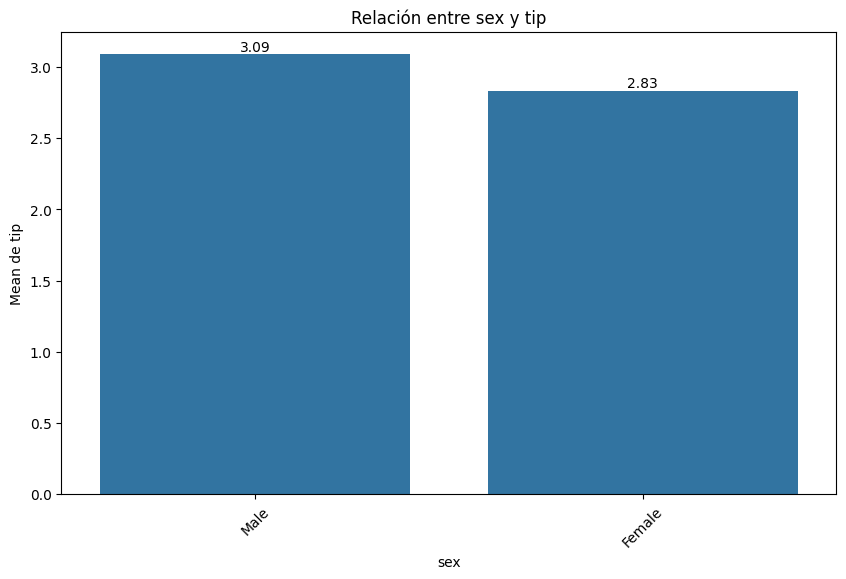

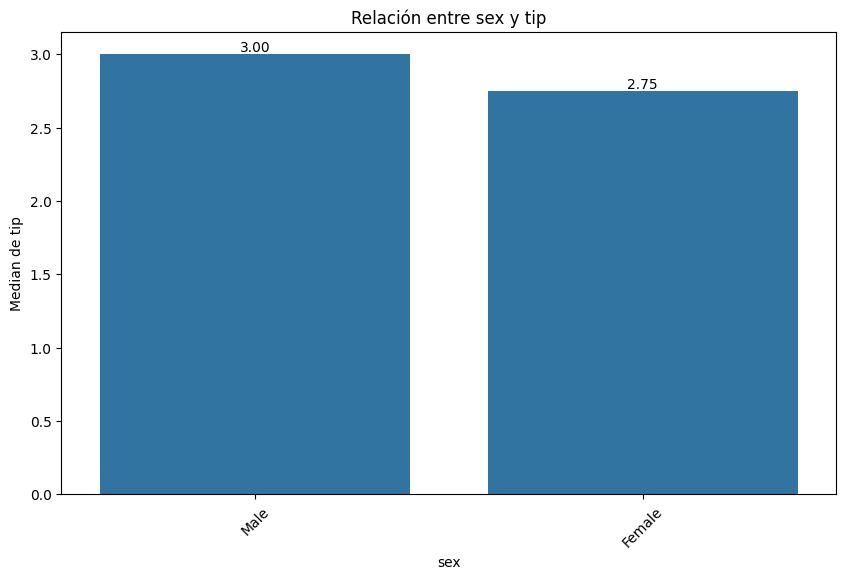

In [24]:
plot_categorical_numerical_relationship(df,"sex","tip",show_values=True, measure="mean")
plot_categorical_numerical_relationship(df,"sex","tip",show_values=True, measure="median")

### Ejercicio 6

Repite el análisis pero esta vez para "tip" y "smoker", añade también el cálculo de la media y de la mediana de la variable continua por cada valor de la variable categórica, y contesta a las siguiente pregunta:
* ¿Existe alguna diferencia visualmente significativa entre las propinas de los grupos de la variable "smoker"?

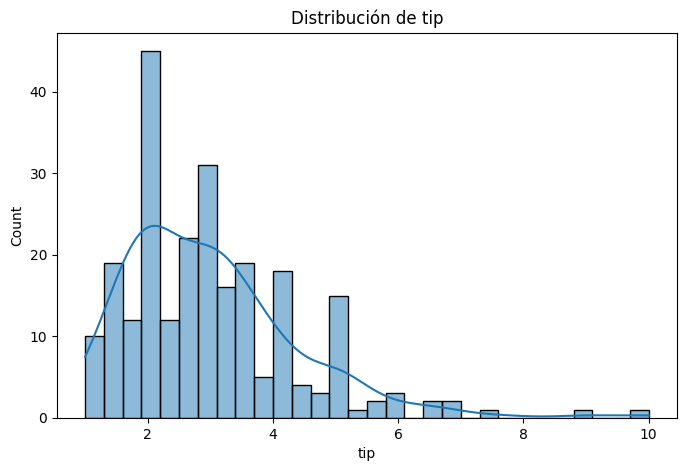

In [27]:
plt.figure(figsize=(8,5)) #cambiar el tamaño
sns.histplot(df["tip"], bins=30, kde=True) #columana a seleccioanr
plt.title("Distribución de tip")
plt.xlabel("tip")
plt.show()

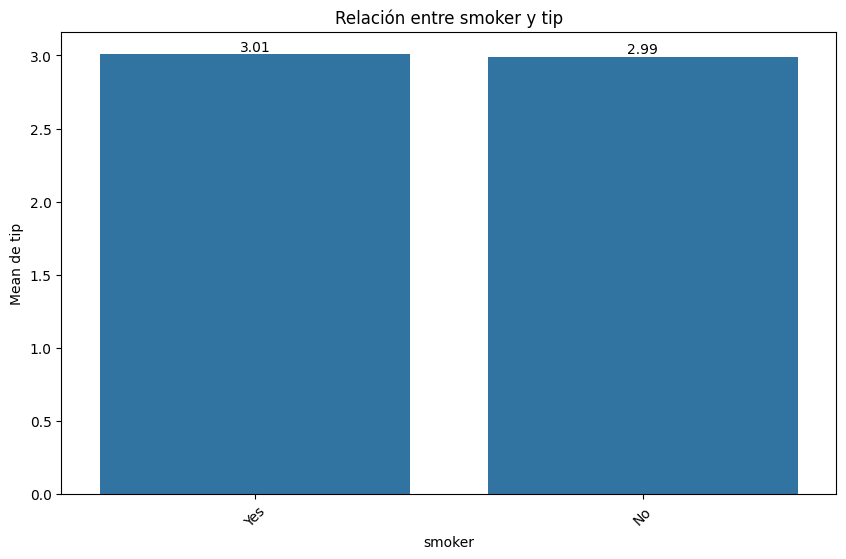

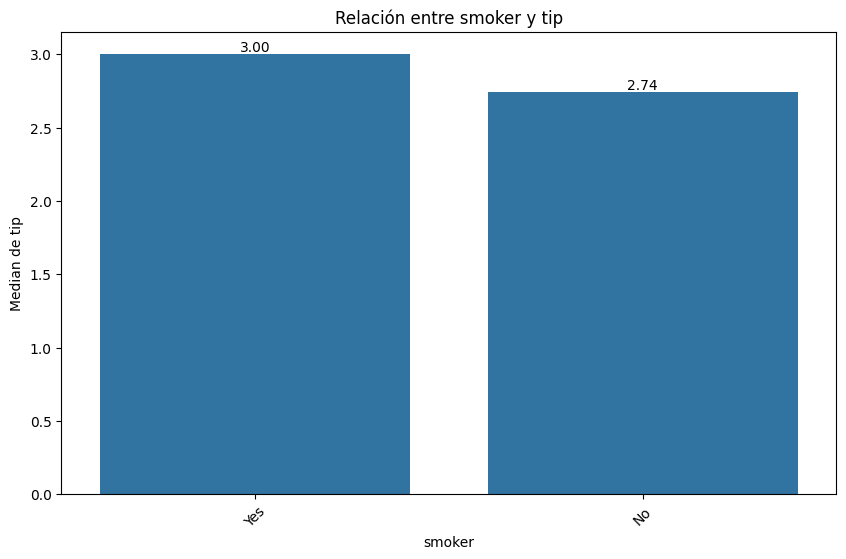

In [25]:
plot_categorical_numerical_relationship(df,"smoker","tip",show_values=True, measure="mean")
plot_categorical_numerical_relationship(df,"smoker","tip",show_values=True, measure="median")

### Ejericicio 7

Carga ahora el datase de accidentes de coches, que se encuentra en la ruta "./data/car_crashes.csv" y deshazte de las columnas innecesarias

In [33]:
df=pd.read_csv("./data/car_crashes.csv",sep="|")
display(df)

,Unnamed: 0,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


In [34]:
df.dtypes

Unnamed: 0          int64
total             float64
speeding          float64
alcohol           float64
not_distracted    float64
no_previous       float64
ins_premium       float64
ins_losses        float64
abbrev                str
dtype: object

In [35]:
df.describe()

,Unnamed: 0,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,25.000000,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,14.866069,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,0.000000,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.500000,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,25.000000,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,37.500000,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,50.000000,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000


In [36]:
cardinalidad(df,10,0.10)

,columna,cardinalidad,porcentaje_cardinalidad,tipo
0,Unnamed: 0,51,1.000000,Numerica Continua
1,total,45,0.882353,Numerica Continua
2,speeding,50,0.980392,Numerica Continua
3,alcohol,50,0.980392,Numerica Continua
4,not_distracted,50,0.980392,Numerica Continua
5,no_previous,50,0.980392,Numerica Continua
6,ins_premium,51,1.000000,Numerica Continua
7,ins_losses,51,1.000000,Numerica Continua
8,abbrev,51,1.000000,Numerica Continua


### Ejercicio 8

Haz un analisis bivairante entre "total" y "speeding". Muestra su diagrama de dispersión y su valor de correlación de pearson obtenido con pandas. Luego contesta a la siguiente pregunta
* ¿Existe alguna relación visual entre las variables?¿Y numérica?

In [37]:
from bootcampviztools import grafico_dispersion_con_correlacion

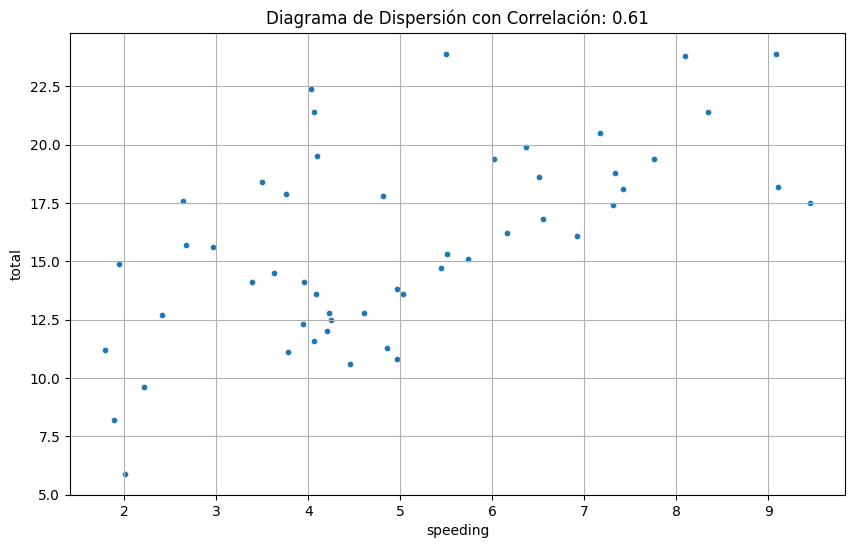

In [39]:
grafico_dispersion_con_correlacion(df,"speeding","total",tamano_puntos=20,mostrar_correlacion=True)

### Ejercicio 9

Usa scipy tal como lo hicimos en el workout para hacer el test de correlación. ¿Cuál es el p-value?¿Qué podemos decir de la correlación lineal entre "total" y "speeding"?